# Xia et al. (2025) CVaR 配电网风险调度：方法级复现

论文：**Source-network-load-storage collaborated two-stage power dispatch of active distribution network with conditional value-at-risk**  
期刊：*International Journal of Electrical Power & Energy Systems*, 172 (2025) 111120  
DOI: `10.1016/j.ijepes.2025.111120`

本 Notebook 复现论文最关键的实验链路：

> **风/光/负荷预测误差 → 1000 个不确定场景 → 20 个典型场景 → IEEE 33 节点 → 储能功率序列 → CVaR 尾部风险 → 风险厌恶调度**

目标不是逐小数点复现，而是像之前的论文复现一样做 **method-level clean-room reproduction**：把论文的核心机制跑通，并明确哪些地方由论文直接给出、哪些地方因为数据/代码未公开而采用透明的替代假设。

## 0. 官方实现检查与复现边界

在制作此复现前，按论文标题、DOI、第一作者和关键词检索了 GitHub/网页公开资源：**没有找到作者公开的官方代码仓库或数据仓库**。论文正文的 Data availability 仅写 **“Data will be made available on request”**；原文实现使用 **MATLAB + YALMIP + GUROBI**，并将非线性模型转为 MISOCP。

因此这里不能声称“官方数值复现”。以下内容尽量保留论文公开的骨架：

- IEEE 33 节点，12.66 kV；
- WT：17、32 节点，各 0.9 MW；
- PV：21、24 节点，各 0.6 MW；
- ESS：15 节点 1.8 MWh / 0.3 MW；32 节点 1.0 MWh / 0.2 MW；
- 1000 个风光不确定场景 → 20 个典型场景；
- 24 h、1 h 时间分辨率；
- 峰谷电价沿用论文 Table 1；
- CVaR 在风险调度目标中作为尾部风险项；Case 3 使用论文给出的 `ωp=0.1, ωe=0.9` 思路。

为了让 Notebook 在普通 Python 环境中可运行，做了几项关键简化：

1. 论文的 WT/PV 历史数据、TSL 参数、Fig. 8 原始曲线未公开；这里按 Fig. 8 的趋势构造 24 h 基准曲线，并用 Student-t location-scale + 正态负荷误差生成不确定场景。
2. 原文用 PED 保持空间相关、fast-forward 做场景削减；这里用 **Gaussian copula + 时空相关矩阵** 生成相关误差，再实现 fast-forward reduction。
3. 原文联合优化网络重构、OLTC、CB、SOP、SVC、DR、ESS；这里聚焦 **ESS + 网侧购售电**，不复制其它灵活资源。
4. 原文用 DistFlow + 二阶锥松弛；这里用 **LinDistFlow** 近似关键末端节点电压，便于用 SciPy/HiGHS 直接求解线性规划。
5. 原文没有给出数值 `β`；这里默认 `β=0.95`，并在后面做敏感性讨论。

所以判断标准是：**是否复现论文的机制与方向性结论，而不是是否复现 Table 4 的每个数字。**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc, norm, t as student_t
from scipy.spatial.distance import cdist
from scipy.optimize import linprog
from scipy.sparse import csr_matrix

np.set_printoptions(precision=4, suppress=True)
SEED = 123
rng = np.random.default_rng(SEED)

## 1. IEEE 33 节点与论文设备位置

基准网络采用标准 Baran–Wu / MATPOWER `case33bw` 参数。标准系统总负荷为 **3.715 MW + j2.3 MVar**，与论文 Case study 给出的总负荷一致。

In [2]:
# Standard IEEE 33-bus data (MW / MVAr; branch R/X in ohm)
loads = {
2:(0.100,0.060),3:(0.090,0.040),4:(0.120,0.080),5:(0.060,0.030),6:(0.060,0.020),
7:(0.200,0.100),8:(0.200,0.100),9:(0.060,0.020),10:(0.060,0.020),11:(0.045,0.030),
12:(0.060,0.035),13:(0.060,0.035),14:(0.120,0.080),15:(0.060,0.010),16:(0.060,0.020),
17:(0.060,0.020),18:(0.090,0.040),19:(0.090,0.040),20:(0.090,0.040),21:(0.090,0.040),
22:(0.090,0.040),23:(0.090,0.050),24:(0.420,0.200),25:(0.420,0.200),26:(0.060,0.025),
27:(0.060,0.025),28:(0.060,0.020),29:(0.120,0.070),30:(0.200,0.600),31:(0.150,0.070),
32:(0.210,0.100),33:(0.060,0.040)
}
branches = [
(1,2,0.0922,0.0470),(2,3,0.4930,0.2511),(3,4,0.3660,0.1864),(4,5,0.3811,0.1941),
(5,6,0.8190,0.7070),(6,7,0.1872,0.6188),(7,8,1.7114,1.2351),(8,9,1.0300,0.7400),
(9,10,1.0440,0.7400),(10,11,0.1966,0.0650),(11,12,0.3744,0.1238),(12,13,1.4680,1.1550),
(13,14,0.5416,0.7129),(14,15,0.5910,0.5260),(15,16,0.7463,0.5450),(16,17,1.2890,1.7210),
(17,18,0.7320,0.5740),(2,19,0.1640,0.1565),(19,20,1.5042,1.3554),(20,21,0.4095,0.4784),
(21,22,0.7089,0.9373),(3,23,0.4512,0.3083),(23,24,0.8980,0.7091),(24,25,0.8960,0.7011),
(6,26,0.2030,0.1034),(26,27,0.2842,0.1447),(27,28,1.0590,0.9337),(28,29,0.8042,0.7006),
(29,30,0.5075,0.2585),(30,31,0.9744,0.9630),(31,32,0.3105,0.3619),(32,33,0.3410,0.5302),
]

children={i:[] for i in range(1,34)}
parent={}
for a,b,r,x in branches:
    children[a].append(b); parent[b]=a

def descendants(i):
    out=[i]
    for c in children[i]: out.extend(descendants(c))
    return out

desc_sets={i:set(descendants(i)) for i in range(1,34)}
baseKV=12.66; baseMVA=10.0; zbase=baseKV**2/baseMVA
P0=np.zeros(34); Q0=np.zeros(34)
for i,(p,q) in loads.items(): P0[i]=p; Q0[i]=q

print('Total P/Q load =', P0.sum(), 'MW /', Q0.sum(), 'MVAr')
print('Paper DG/ESS placements: WT@17,32; PV@21,24; ESS@15,32')

Total P/Q load = 3.715 MW / 2.3000000000000003 MVAr
Paper DG/ESS placements: WT@17,32; PV@21,24; ESS@15,32


## 2. 24 h 基准曲线与论文电价

论文 Fig. 8 给出 WT/PV/load distribution factors，但未公开原始数字。下面用其趋势构造可重复的近似曲线。电价则直接采用论文 Table 1。

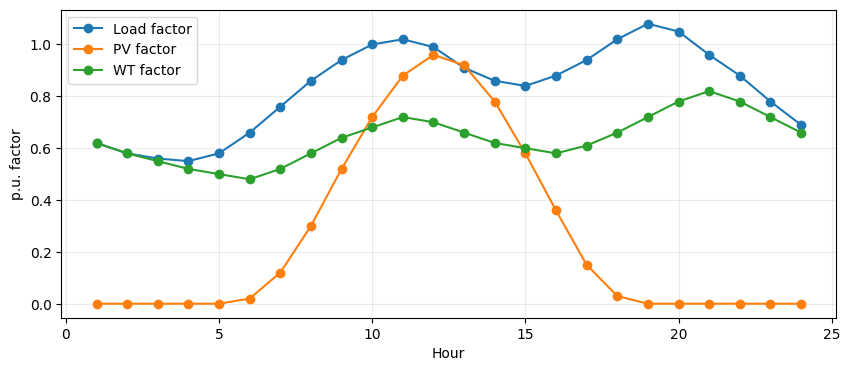

In [3]:
hours=np.arange(1,25)
load_scale=np.array([0.62,0.58,0.56,0.55,0.58,0.66,0.76,0.86,0.94,1.00,1.02,0.99,
                     0.91,0.86,0.84,0.88,0.94,1.02,1.08,1.05,0.96,0.88,0.78,0.69])
pv_cf=np.array([0,0,0,0,0,0.02,0.12,0.30,0.52,0.72,0.88,0.96,0.92,0.78,0.58,0.36,0.15,0.03,0,0,0,0,0,0])
wind_cf=np.array([0.62,0.58,0.55,0.52,0.50,0.48,0.52,0.58,0.64,0.68,0.72,0.70,
                  0.66,0.62,0.60,0.58,0.61,0.66,0.72,0.78,0.82,0.78,0.72,0.66])
price=np.array([400]*8+[800,800,1200,1200,800,800,800,1200,1200,1200,1200,1200,1200,1200,800,800],dtype=float)

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(hours, load_scale, marker='o', label='Load factor')
ax.plot(hours, pv_cf, marker='o', label='PV factor')
ax.plot(hours, wind_cf, marker='o', label='WT factor')
ax.set_xlabel('Hour'); ax.set_ylabel('p.u. factor'); ax.grid(alpha=.25); ax.legend(); plt.show()

## 3. 1000 个时空相关场景

论文做法：WT/PV 预测误差用 location-scale t 分布，负荷预测误差用正态分布；考虑预测误差随时间变化，并保留多个风/光站点之间的空间相关性。

这里用一个可执行的替代实现：

- Latin Hypercube Sampling；
- Gaussian copula 构造 24 h 时间相关和站点空间相关；
- PV/WT 边缘误差映射为 Student-t；
- 负荷误差映射为 Normal；
- 输出裁剪在物理容量范围内。

In [4]:
pv_caps=np.array([0.6,0.6]); wind_caps=np.array([0.9,0.9])
n_raw=1000; D=5*24
sampler=qmc.LatinHypercube(d=D, seed=SEED)
U=sampler.random(n_raw); Z=norm.ppf(U)

rho_t=.65
Tcorr=rho_t**np.abs(np.subtract.outer(np.arange(24),np.arange(24)))
Vcorr=np.array([
[1.0,.75,.20,.15,.10],
[.75,1.0,.15,.20,.10],
[.20,.15,1.0,.65,.10],
[.15,.20,.65,1.0,.10],
[.10,.10,.10,.10,1.0],
])
C=np.kron(Tcorr,Vcorr)
L=np.linalg.cholesky(C+1e-8*np.eye(D))
Zc=Z@L.T
Uc=np.clip(norm.cdf(Zc),1e-6,1-1e-6).reshape(n_raw,24,5)

pv_sigma=0.08+0.08*pv_cf
wind_sigma=np.full(24,0.14)
load_sigma=0.04+0.01*(load_scale>0.95)
df=5
pv_scen=np.zeros((n_raw,24,2)); wind_scen=np.zeros((n_raw,24,2)); load_scen=np.zeros((n_raw,24))
for h in range(24):
    for k in range(2):
        e=student_t.ppf(Uc[:,h,k],df=df)*pv_sigma[h]*pv_caps[k]
        pv_scen[:,h,k]=np.clip(pv_cf[h]*pv_caps[k]+e,0,pv_caps[k])
    for k in range(2):
        e=student_t.ppf(Uc[:,h,2+k],df=df)*wind_sigma[h]*wind_caps[k]
        wind_scen[:,h,k]=np.clip(wind_cf[h]*wind_caps[k]+e,0,wind_caps[k])
    e=norm.ppf(Uc[:,h,4])*load_sigma[h]
    load_scen[:,h]=np.clip(load_scale[h]*(1+e),0.4,1.25)

print('raw scenarios:', pv_scen.shape[0])

raw scenarios: 1000


## 4. Fast-forward：1000 → 20 个典型场景

与论文一致保留“先大规模采样、再降维到 20 个典型场景”的实验结构。这里直接实现基于几何距离的 forward selection，并把被删场景的概率合并到最近代表场景。

reduced scenarios: 20 probability sum: 1.0 range: (np.float64(0.024), np.float64(0.08500000000000002))


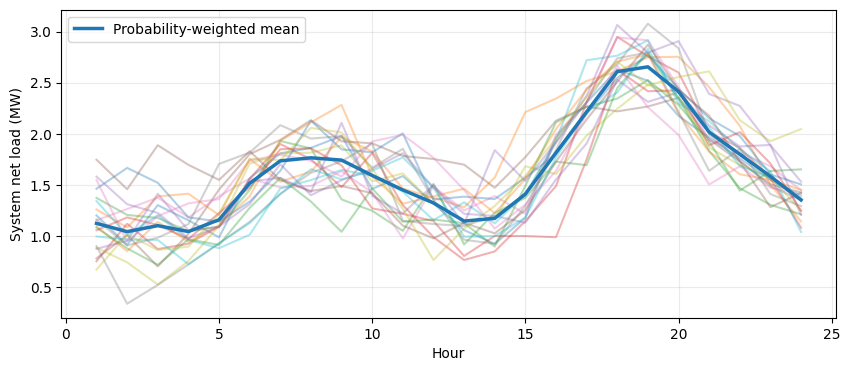

In [5]:
X=np.concatenate([
    pv_scen.reshape(n_raw,-1)/0.6,
    wind_scen.reshape(n_raw,-1)/0.9,
    load_scen
],axis=1)

def fast_forward_reduce(X,k,probs=None):
    n=len(X)
    if probs is None: probs=np.full(n,1/n)
    D=cdist(X,X)
    selected=[]; nearest=np.full(n,np.inf); candidates=set(range(n))
    for _ in range(k):
        best=None; best_obj=np.inf; best_nearest=None
        for j in candidates:
            candidate=np.minimum(nearest,D[:,j])
            obj=float(probs@candidate)
            if obj<best_obj:
                best_obj=obj; best=j; best_nearest=candidate
        selected.append(best); candidates.remove(best); nearest=best_nearest
    sel=np.array(selected)
    assignment=D[:,sel].argmin(axis=1)
    p_red=np.array([probs[assignment==j].sum() for j in range(k)])
    return sel,p_red,assignment

sel,p_red,assignment=fast_forward_reduce(X,20)
pvR=pv_scen[sel]; windR=wind_scen[sel]; loadR=load_scen[sel]
print('reduced scenarios:',len(sel),'probability sum:',p_red.sum(),'range:',(p_red.min(),p_red.max()))

# Show reduced system-level net-load scenarios
net_load_plot=3.715*loadR-pvR.sum(axis=2)-windR.sum(axis=2)
fig,ax=plt.subplots(figsize=(10,4))
for s in range(20): ax.plot(hours,net_load_plot[s],alpha=.35)
ax.plot(hours,(p_red[:,None]*net_load_plot).sum(0),linewidth=2.5,label='Probability-weighted mean')
ax.set_xlabel('Hour');ax.set_ylabel('System net load (MW)');ax.grid(alpha=.25);ax.legend();plt.show()

## 5. LinDistFlow 与储能对节点电压的灵敏度

论文使用 DistFlow + MISOCP。本复现为了保持单 Notebook、无需商用求解器，使用 LinDistFlow：

\[
v_j \approx v_i - 2(r_{ij}P_{ij}+x_{ij}Q_{ij})
\]

并把 ESS 节点 15、32 的充放电对末端节点电压的影响写成线性灵敏度。重点监视四个典型末端节点：18、22、25、33。

In [6]:
def lindistflow_v2(Pnode,Qnode):
    v=np.ones(34); Pflow=np.zeros(len(branches)); Qflow=np.zeros(len(branches))
    for ei,(a,b,r,x) in enumerate(branches):
        ds=desc_sets[b]
        P=Pnode[list(ds)].sum(); Q=Qnode[list(ds)].sum()
        Pflow[ei]=P; Qflow[ei]=Q
        v[b]=v[a]-2*((r/zbase)*(P/baseMVA)+(x/zbase)*(Q/baseMVA))
    return v,Pflow,Qflow

crit=[18,22,25,33]; ess_buses=[15,32]
sens=np.zeros((len(crit),2))
for k,bus in enumerate(ess_buses):
    p=np.zeros(34); q=np.zeros(34); p[bus]=1.0
    v,_,_=lindistflow_v2(p,q)
    sens[:,k]=v[crit]-1.0

S=20; T=24
base_v=np.zeros((S,T,len(crit))); net_total=np.zeros((S,T))
for s in range(S):
    for h in range(T):
        P=P0*loadR[s,h]; Q=Q0*loadR[s,h]
        P=P.copy(); Q=Q.copy()
        P[21]-=pvR[s,h,0]; P[24]-=pvR[s,h,1]
        P[17]-=windR[s,h,0]; P[32]-=windR[s,h,1]
        v,_,_=lindistflow_v2(P,Q)
        base_v[s,h]=v[crit]; net_total[s,h]=P.sum()

print('Without ESS, critical-bus voltage range:',np.sqrt(base_v).min(),np.sqrt(base_v).max())
print('Voltage sensitivity (squared-voltage change per +1 MW ESS charging load):')
display(pd.DataFrame(sens,index=[f'bus {b}' for b in crit],columns=['ESS@15','ESS@32']))

Without ESS, critical-bus voltage range: 0.9358001207338944 1.020922466055322
Voltage sensitivity (squared-voltage change per +1 MW ESS charging load):


,ESS@15,ESS@32
bus 18,-0.115994,-0.026845
bus 22,-0.001151,-0.001151
bus 25,-0.007302,-0.007302
bus 33,-0.026845,-0.078541


## 6. CVaR 风险调度：把“尾部坏场景”放进序列搜索目标

这里直接复现最重要的机制。

储能决策仍然是一条 24 h 的充/放电序列：

\[
x=[P^{ch}_{1,1:24},P^{dis}_{1,1:24},P^{ch}_{2,1:24},P^{dis}_{2,1:24}]
\]

约束包括：

- 充放电功率上限；
- SOC 状态转移；
- SOC 范围；
- 日末 SOC 回到日初；
- 每个不确定场景下的功率平衡。

对每个场景得到两类损失：

1. `economic loss`：购电 + 储能吞吐成本；
2. `network risk loss`：关键节点超出 0.94–1.06 p.u. 的电压越限代理损失。

Case 2 只最小化概率加权平均损失；Case 3 再加入 CVaR：

\[
\min (1-\lambda)\mathbb E[L]+\lambda\operatorname{CVaR}_{\beta}(L)
\]

这里 `λ=0.9` 对应论文 Case 3 强调风险项的思路，`β=0.95` 是本复现假设。

In [7]:
def solve_dispatch(lambda_risk=0.0,beta=0.95,kv=50000.0,cycle_cost=30.0,export_frac=0.15,vmin=0.94,vmax=1.06):
    S,T,K,B=20,24,2,len(crit)
    idx={}; n=0
    def alloc(name,shape):
        nonlocal n
        arr=np.arange(n,n+int(np.prod(shape))).reshape(shape); idx[name]=arr; n+=arr.size; return arr
    pch=alloc('pch',(K,T)); pdis=alloc('pdis',(K,T)); soc=alloc('soc',(K,T+1))
    gimp=alloc('gimp',(S,T)); gexp=alloc('gexp',(S,T))
    vlo=alloc('vlo',(S,T,B)); vhi=alloc('vhi',(S,T,B))
    eta_c=alloc('eta_c',(1,)); zc=alloc('zc',(S,)); eta_v=alloc('eta_v',(1,)); zv=alloc('zv',(S,))

    c=np.zeros(n)
    for s in range(S):
        ps=p_red[s]
        for h in range(T):
            c[gimp[s,h]]+=(1-lambda_risk)*ps*price[h]
            c[gexp[s,h]]+=(1-lambda_risk)*ps*(-export_frac*price[h])
            for k in range(K):
                c[pch[k,h]]+=(1-lambda_risk)*ps*cycle_cost
                c[pdis[k,h]]+=(1-lambda_risk)*ps*cycle_cost
            for b in range(B):
                c[vlo[s,h,b]]+=(1-lambda_risk)*ps*kv/B
                c[vhi[s,h,b]]+=(1-lambda_risk)*ps*kv/B
    c[eta_c[0]]+=lambda_risk; c[zc]+=lambda_risk*p_red/(1-beta)
    c[eta_v[0]]+=lambda_risk; c[zv]+=lambda_risk*p_red/(1-beta)

    # Equalities: SOC + scenario power balance
    rr=[];cc=[];dd=[];beq=[];r=0
    caps=np.array([1.8,1.0]); pmax=np.array([0.3,0.2]); eta_ch=.95; eta_dis=.95; init=.5
    for k in range(K):
        rr.append(r);cc.append(soc[k,0]);dd.append(1);beq.append(caps[k]*init);r+=1
        for h in range(T):
            for col,val in [(soc[k,h+1],1),(soc[k,h],-1),(pch[k,h],-eta_ch),(pdis[k,h],1/eta_dis)]:
                rr.append(r);cc.append(col);dd.append(val)
            beq.append(0);r+=1
        rr.append(r);cc.append(soc[k,T]);dd.append(1);beq.append(caps[k]*init);r+=1
    for s in range(S):
        for h in range(T):
            for col,val in [(gimp[s,h],1),(gexp[s,h],-1)]: rr.append(r);cc.append(col);dd.append(val)
            for k in range(K):
                rr += [r,r]; cc += [pdis[k,h],pch[k,h]]; dd += [1,-1]
            beq.append(net_total[s,h]);r+=1
    Aeq=csr_matrix((dd,(rr,cc)),shape=(r,n)); beq=np.array(beq)

    # Inequalities: voltage slacks + CVaR linearization
    rr=[];cc=[];dd=[];bub=[];r=0
    lo2=vmin**2; hi2=vmax**2
    for s in range(S):
        for h in range(T):
            for bi in range(B):
                # vlo >= lo2 - v2
                rr.append(r);cc.append(vlo[s,h,bi]);dd.append(-1)
                for k in range(K): rr += [r,r];cc += [pch[k,h],pdis[k,h]];dd += [-sens[bi,k],sens[bi,k]]
                bub.append(base_v[s,h,bi]-lo2);r+=1
                # vhi >= v2 - hi2
                rr.append(r);cc.append(vhi[s,h,bi]);dd.append(-1)
                for k in range(K): rr += [r,r];cc += [pch[k,h],pdis[k,h]];dd += [sens[bi,k],-sens[bi,k]]
                bub.append(hi2-base_v[s,h,bi]);r+=1

    # Economic CVaR: z_s >= cost_s - eta
    for s in range(S):
        for h in range(T):
            rr += [r,r];cc += [gimp[s,h],gexp[s,h]];dd += [price[h],-export_frac*price[h]]
            for k in range(K): rr += [r,r];cc += [pch[k,h],pdis[k,h]];dd += [cycle_cost,cycle_cost]
        rr += [r,r];cc += [eta_c[0],zc[s]];dd += [-1,-1];bub.append(0);r+=1

    # Network-risk CVaR
    for s in range(S):
        for h in range(T):
            for bi in range(B): rr += [r,r];cc += [vlo[s,h,bi],vhi[s,h,bi]];dd += [kv/B,kv/B]
        rr += [r,r];cc += [eta_v[0],zv[s]];dd += [-1,-1];bub.append(0);r+=1

    Aub=csr_matrix((dd,(rr,cc)),shape=(r,n)); bub=np.array(bub)
    bounds=[(0,None)]*n
    for k in range(K):
        for h in range(T): bounds[pch[k,h]]=(0,pmax[k]); bounds[pdis[k,h]]=(0,pmax[k])
        for h in range(T+1): bounds[soc[k,h]]=(0.1*caps[k],caps[k])
    for s in range(S):
        for h in range(T): bounds[gimp[s,h]]=(0,10);bounds[gexp[s,h]]=(0,10)
    bounds[eta_c[0]]=(0,None);bounds[eta_v[0]]=(0,None)

    result=linprog(c,A_ub=Aub,b_ub=bub,A_eq=Aeq,b_eq=beq,bounds=bounds,method='highs')
    if not result.success: raise RuntimeError(result.message)
    pars=dict(kv=kv,cycle_cost=cycle_cost,export_frac=export_frac,beta=beta,lambda_risk=lambda_risk,vmin=vmin,vmax=vmax)
    return result,idx,pars

def weighted_cvar(vals,probs,beta):
    vals=np.asarray(vals); candidates=np.unique(vals)
    objectives=[eta+np.sum(probs*np.maximum(vals-eta,0))/(1-beta) for eta in candidates]
    j=int(np.argmin(objectives)); return float(objectives[j]),float(candidates[j])

def evaluate(result,idx,pars):
    x=result.x; pch=x[idx['pch']];pdis=x[idx['pdis']];soc=x[idx['soc']]
    gimp=x[idx['gimp']];gexp=x[idx['gexp']]
    v2=np.zeros((20,24,len(crit)))
    for s in range(20):
        for h in range(24): v2[s,h]=base_v[s,h]+sens@(pch[:,h]-pdis[:,h])
    v=np.sqrt(np.maximum(v2,0))
    lo=np.maximum(0,pars['vmin']-v);hi=np.maximum(0,v-pars['vmax'])
    lo2=np.maximum(0,pars['vmin']**2-v2);hi2=np.maximum(0,v2-pars['vmax']**2)
    cost=np.array([np.sum(price*gimp[s]-pars['export_frac']*price*gexp[s])+pars['cycle_cost']*np.sum(pch+pdis) for s in range(20)])
    risk=pars['kv']/len(crit)*np.sum(lo2+hi2,axis=(1,2))
    cc,varc=weighted_cvar(cost,p_red,pars['beta']); cr,varr=weighted_cvar(risk,p_red,pars['beta'])
    return dict(pch=pch,pdis=pdis,soc=soc,gimp=gimp,gexp=gexp,v=v,cost_s=cost,risk_s=risk,
                expected_cost=float(p_red@cost),expected_risk=float(p_red@risk),cvar_cost=cc,cvar_risk=cr,
                violation_pu_h=float(np.sum(p_red[:,None,None]*(lo+hi))),
                violation_probability=float(np.sum(p_red[:,None,None]*((lo+hi)>1e-9))/(24*len(crit))),
                vmin=float(v.min()),vmax=float(v.max()),
                peak_import=float((p_red[:,None]*gimp).sum(0).max()))

## 7. 三个 Case：无储能 / 期望调度 / CVaR 风险调度

对应论文 Table 4 的比较逻辑，而不是追求完全相同的数值：

- **Case 1**：不使用 ESS；
- **Case 2**：使用 ESS，但不强调尾部风险（`λ=0`）；
- **Case 3**：使用 ESS + CVaR 尾部风险（`λ=0.9`）。

In [8]:
def evaluate_no_ess(kv=50000,export_frac=.15,beta=.95,vmin=.94,vmax=1.06):
    gimp=np.maximum(net_total,0);gexp=np.maximum(-net_total,0);v=np.sqrt(np.maximum(base_v,0))
    lo=np.maximum(0,vmin-v);hi=np.maximum(0,v-vmax)
    lo2=np.maximum(0,vmin**2-base_v);hi2=np.maximum(0,base_v-vmax**2)
    cost=np.array([np.sum(price*gimp[s]-export_frac*price*gexp[s]) for s in range(20)])
    risk=kv/len(crit)*np.sum(lo2+hi2,axis=(1,2))
    cc,_=weighted_cvar(cost,p_red,beta);cr,_=weighted_cvar(risk,p_red,beta)
    return dict(expected_cost=float(p_red@cost),expected_risk=float(p_red@risk),cvar_cost=cc,cvar_risk=cr,
                violation_pu_h=float(np.sum(p_red[:,None,None]*(lo+hi))),
                violation_probability=float(np.sum(p_red[:,None,None]*((lo+hi)>1e-9))/(24*len(crit))),
                vmin=float(v.min()),vmax=float(v.max()),peak_import=float((p_red[:,None]*gimp).sum(0).max()),
                v=v,gimp=gimp)

case1=evaluate_no_ess()
r2,i2,p2=solve_dispatch(lambda_risk=0.0,beta=.95);case2=evaluate(r2,i2,p2)
r3,i3,p3=solve_dispatch(lambda_risk=0.9,beta=.95);case3=evaluate(r3,i3,p3)

summary=pd.DataFrame([
    ['Case 1: no ESS',case1['expected_cost'],case1['cvar_cost'],case1['cvar_risk'],case1['violation_pu_h'],case1['vmin'],case1['peak_import']],
    ['Case 2: expected-value ESS',case2['expected_cost'],case2['cvar_cost'],case2['cvar_risk'],case2['violation_pu_h'],case2['vmin'],case2['peak_import']],
    ['Case 3: CVaR ESS',case3['expected_cost'],case3['cvar_cost'],case3['cvar_risk'],case3['violation_pu_h'],case3['vmin'],case3['peak_import']],
],columns=['case','expected economic cost','CVaR economic cost','CVaR network risk','voltage violation p.u.-h','minimum voltage','peak expected import MW'])
display(summary.round(4))

,case,expected economic cost,CVaR economic cost,CVaR network risk,voltage violation p.u.-h,minimum voltage,peak expected import MW
0,Case 1: no ESS,34146.6221,38124.4500,98.2734,0.0007,0.9358,2.6546
1,Case 2: expected-value ESS,32747.9489,36725.7768,67.5372,0.0004,0.9371,2.4129
2,Case 3: CVaR ESS,32770.3630,36748.1908,0.0000,0.0000,0.9400,2.5262


### 结果怎么读

复现应出现和论文一致的**方向性结果**：

- 从 Case 1 → Case 2：储能的时移作用降低平均购电成本和峰值购电；
- 从 Case 2 → Case 3：平均经济成本可能小幅上升，但**尾部网络风险显著下降**；
- 这就是 CVaR 的作用：它不是额外生成场景，而是给同一条控制序列增加“坏尾部表现”的评价目标。

原论文 Table 4 同样表现出 Case 3 相比 Case 2：`fm` 上升，而 `fr`、尤其高风险越限损失下降。

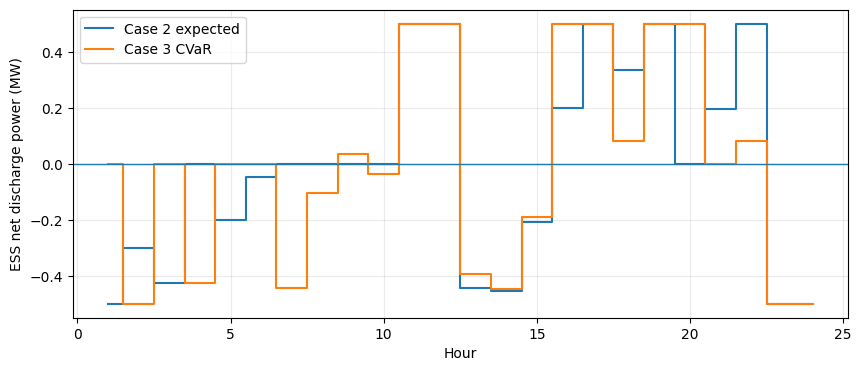

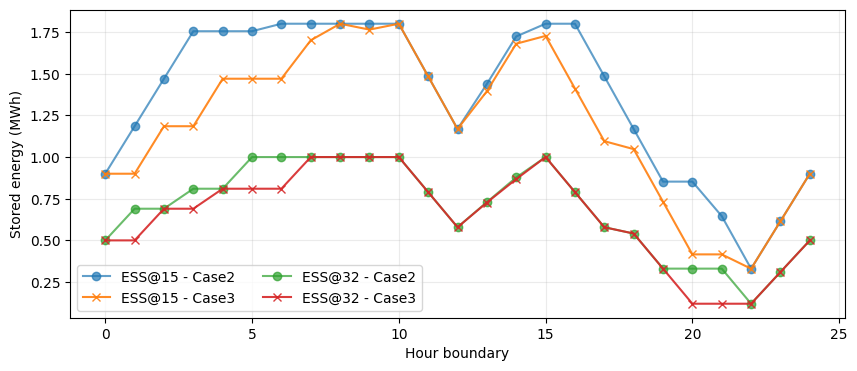

In [9]:
fig,ax=plt.subplots(figsize=(10,4))
for label,case in [('Case 2 expected',case2),('Case 3 CVaR',case3)]:
    net=(case['pdis']-case['pch']).sum(axis=0)
    ax.step(hours,net,where='mid',label=label)
ax.axhline(0,linewidth=1)
ax.set_xlabel('Hour');ax.set_ylabel('ESS net discharge power (MW)');ax.grid(alpha=.25);ax.legend();plt.show()

fig,ax=plt.subplots(figsize=(10,4))
for k,name in enumerate(['ESS@15','ESS@32']):
    ax.plot(np.arange(25),case2['soc'][k],marker='o',alpha=.7,label=f'{name} - Case2')
    ax.plot(np.arange(25),case3['soc'][k],marker='x',alpha=.9,label=f'{name} - Case3')
ax.set_xlabel('Hour boundary');ax.set_ylabel('Stored energy (MWh)');ax.grid(alpha=.25);ax.legend(ncol=2);plt.show()

## 8. 电压风险：CVaR 为什么会改变储能序列

下面不只看“平均电压”，而是看 20 个不确定场景中每小时的最坏末端电压。若 Case 3 在少量高负荷/低新能源场景下主动保留更多放电能力，最坏电压会得到改善。

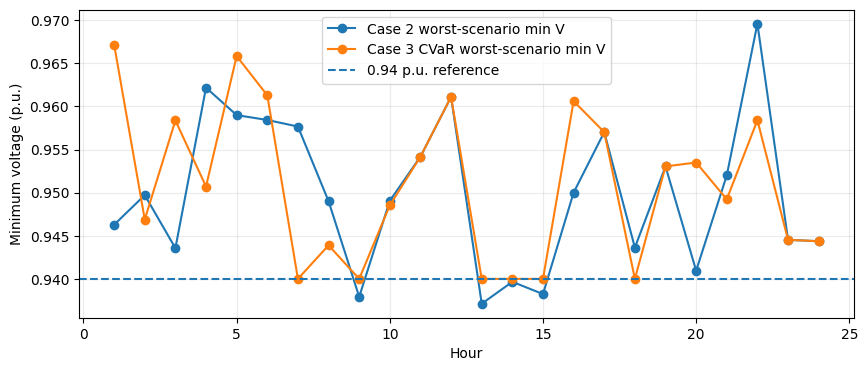

In [10]:
worst2=case2['v'].min(axis=(0,2));worst3=case3['v'].min(axis=(0,2))
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(hours,worst2,marker='o',label='Case 2 worst-scenario min V')
ax.plot(hours,worst3,marker='o',label='Case 3 CVaR worst-scenario min V')
ax.axhline(.94,linestyle='--',label='0.94 p.u. reference')
ax.set_xlabel('Hour');ax.set_ylabel('Minimum voltage (p.u.)');ax.grid(alpha=.25);ax.legend();plt.show()

## 9. 风险权重敏感性：平均经济性 vs 尾部风险

论文强调的其实不是“CVaR 一定让所有指标都更好”，而是一个典型的 risk–cost trade-off。这里把 `λ` 从 0 调到 0.9，看同一模型如何从“更在意平均成本”逐渐转向“更在意最坏尾部”。

,risk weight λ,expected cost,CVaR network risk,voltage violation p.u.-h,minimum voltage
0,0.00,32747.9489,67.5372,0.0004,0.9371
1,0.25,32748.0645,47.6343,0.0004,0.9380
2,0.50,32770.3630,0.0000,0.0000,0.9400
3,0.75,32770.3630,0.0000,0.0000,0.9400
4,0.90,32770.3630,0.0000,0.0000,0.9400


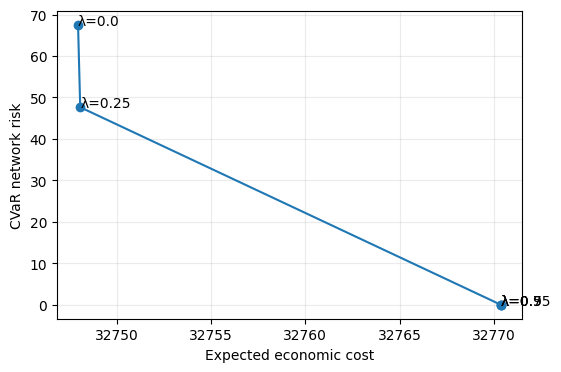

In [11]:
rows=[]
for lam in [0,.25,.5,.75,.9]:
    rr,ii,pp=solve_dispatch(lambda_risk=lam,beta=.95)
    ee=evaluate(rr,ii,pp)
    rows.append([lam,ee['expected_cost'],ee['cvar_risk'],ee['violation_pu_h'],ee['vmin']])
sens_df=pd.DataFrame(rows,columns=['risk weight λ','expected cost','CVaR network risk','voltage violation p.u.-h','minimum voltage'])
display(sens_df.round(4))

fig,ax=plt.subplots(figsize=(6,4))
ax.plot(sens_df['expected cost'],sens_df['CVaR network risk'],marker='o')
for _,r in sens_df.iterrows(): ax.annotate(f"λ={r['risk weight λ']}",(r['expected cost'],r['CVaR network risk']))
ax.set_xlabel('Expected economic cost');ax.set_ylabel('CVaR network risk');ax.grid(alpha=.25);plt.show()

## 10. 与原论文结果对齐：复现了什么，没复现什么

原论文 Table 4：

| Case | `fm` (Yuan) | `fr,c` | `fr,o` | `fr` |
|---|---:|---:|---:|---:|
| Case 1 | 17969 | 20702 | 791 | 21493 |
| Case 2 | 11409 | 14402 | 223 | 14625 |
| Case 3 | 12768 | 13075 | 42 | 13117 |

论文的核心现象是：

> **Case 3 相比 Case 2，平均综合运行成本上升，但高风险场景损失下降，尤其 voltage-overrun risk 大幅下降。**

本 Notebook 复现的就是这个机制：CVaR 把尾部损失加入控制序列的评价函数后，优化器愿意牺牲少量平均经济性来压低极端场景电压风险。

没有逐数值复现的原因不是算法问题，而是论文没有公开足够的原始输入：历史 WT/PV/负荷数据、TSL 参数、完整 modified-33-bus 拓扑/联络开关、SOP/SVC/CB/DR 成本参数、全部权重与 `β`、以及官方 MATLAB/YALMIP 代码。

因此本复现最适合用来理解和验证：

1. **CVaR 到底如何进入调度目标；**
2. **它如何改变原来的储能序列搜索；**
3. **为什么 Case 3 可能“更贵但更安全”；**
4. **未来把 Conformal 场景接到 CVaR 时，中间真正需要的是一组可用于下游 loss 计算的未来场景，而不是只有一个区间上下界。**